In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.svm import SVC


In [3]:
x_toy =np.array([[1,2],[2,3],[4,1],[5,2]])
y_toy=np.array([-1,-1,1,1])

In [6]:
svm_solver=SVC(kernel='linear',C=10000)
svm_solver.fit(x_toy,y_toy)

,C,10000
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
calculated_w=svm_solver.coef_[0]
calculated_b=svm_solver.intercept_[0]
support_vectors=svm_solver.support_vectors_

In [10]:
print("cal_w:",calculated_w)
print("cal_b: ",calculated_b)
print("support_vectors:",support_vectors)

cal_w: [ 0.5 -0.5]
cal_b:  -0.5
support_vectors: [[2. 3.]
 [4. 1.]]


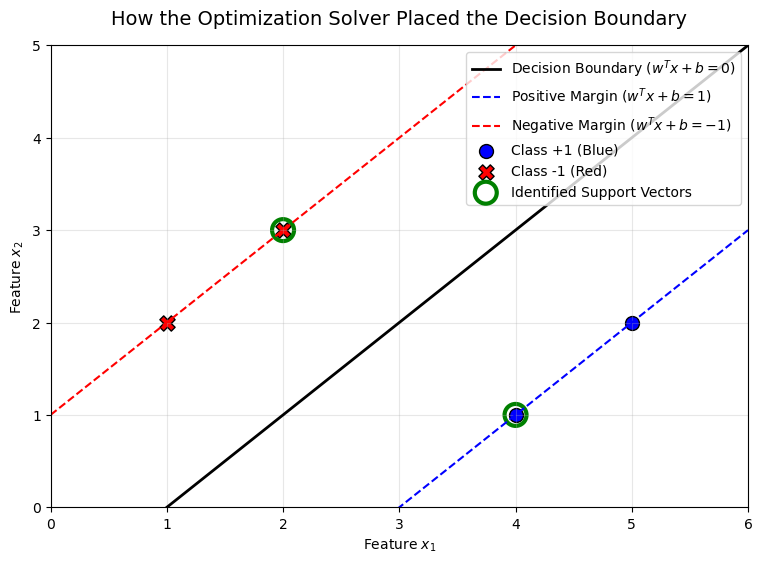

In [12]:
x1_space = np.linspace(0, 6, 100)

# Formula for central hyperplane: w0*x1 + w1*x2 + b = 0 -> x2 = (-w0*x1 - b) / w1
x2_hyperplane = (-calculated_w[0] * x1_space - calculated_b) / calculated_w[1]

# Formula for Positive Margin: w0*x1 + w1*x2 + b = 1 -> x2 = (1 - w0*x1 - b) / w1
x2_pos_margin = (1 - calculated_w[0] * x1_space - calculated_b) / calculated_w[1]

# Formula for Negative Margin: w0*x1 + w1*x2 + b = -1 -> x2 = (-1 - w0*x1 - b) / w1
x2_neg_margin = (-1 - calculated_w[0] * x1_space - calculated_b) / calculated_w[1]

plt.figure(figsize=(9, 6))

# Plot the calculated main decision boundary and margins
plt.plot(x1_space, x2_hyperplane, 'k-', lw=2, label='Decision Boundary ($w^Tx + b = 0$)')
plt.plot(x1_space, x2_pos_margin, 'b--', lw=1.5, label='Positive Margin ($w^Tx + b = 1$)')
plt.plot(x1_space, x2_neg_margin, 'r--', lw=1.5, label='Negative Margin ($w^Tx + b = -1$)')

# Plot the training data points
plt.scatter(x_toy[y_toy==1, 0], x_toy[y_toy==1, 1], color='blue', s=100, edgecolors='k', label='Class +1 (Blue)')
plt.scatter(x_toy[y_toy==-1, 0], x_toy[y_toy==-1, 1], color='red', marker='X', s=120, edgecolors='k', label='Class -1 (Red)')

# Highlight the specific data points chosen by the solver as Support Vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=250, 
            facecolors='none', edgecolors='green', lw=3, label='Identified Support Vectors')

plt.xlim(0, 6)
plt.ylim(0, 5)
plt.xlabel('Feature $x_1$')
plt.ylabel('Feature $x_2$')
plt.title('How the Optimization Solver Placed the Decision Boundary', fontsize=14, pad=15)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()